# Práctica 05 : Manejo de headmaps en Analisis de datos

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

<div style="background: linear-gradient(135deg, #0A4D8C 0%, #052C65 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
Manejo de Heatmaps en Análisis de Datos
</h1>

<p style="color: #D6EAF8; font-size: 1.1em; margin-top: 10px;">
Análisis Exploratorio de Datos (EDA) • Matrices de Correlación •
Mapas de Calor • Descubrimiento de Relaciones entre Variables
</p>

</div>


# Manejo de Mapas de Calor en Análisis de Datos

## Análisis Exploratorio de Datos (EDA) mediante Heatmaps

Los mapas de calor (**Heatmaps**) son una de las herramientas más utilizadas en el análisis exploratorio de datos (EDA), ya que permiten representar visualmente la intensidad de los valores de una matriz mediante una escala de colores. Son especialmente útiles para identificar correlaciones entre variables, detectar patrones, relaciones, agrupamientos y posibles anomalías dentro de un conjunto de datos.

En este cuaderno se realizará un recorrido práctico por el uso de los mapas de calor utilizando Python y sus principales bibliotecas de ciencia de datos. Se aprenderá cómo construir matrices de correlación, interpretar sus resultados y emplear diferentes técnicas de visualización para facilitar el análisis de la información.

El objetivo principal es comprender cómo los heatmaps pueden convertirse en una herramienta esencial para apoyar la toma de decisiones basada en datos y mejorar el proceso de análisis exploratorio.

---

# Contenido

## 1. Preparación del conjunto de datos
- Importación de bibliotecas
- Carga del conjunto de datos
- Exploración inicial

## 2. Comprensión de los Mapas de Calor
- ¿Qué es un Heatmap?
- ¿Para qué sirve?
- Aplicaciones en Ciencia de Datos

## 3. Preparación de los datos
- Limpieza de datos
- Tratamiento de valores faltantes
- Selección de variables numéricas

## 4. Matriz de Correlación
- Correlación de Pearson
- Correlación de Spearman
- Interpretación de coeficientes

## 5. Visualización con Heatmaps
- Heatmap básico con Seaborn
- Personalización de colores
- Etiquetas y anotaciones
- Ajuste del tamaño de la figura

## 6. Interpretación de Resultados
- Variables altamente correlacionadas
- Correlaciones positivas
- Correlaciones negativas
- Variables independientes

## 7. Casos de Uso
- Selección de características (Feature Selection)
- Detección de multicolinealidad
- Identificación de patrones
- Apoyo al modelado predictivo

## 8. Conclusiones
- Principales hallazgos
- Ventajas del uso de Heatmaps
- Buenas prácticas en el análisis exploratorio

---

# 1. Preparación del conjunto de datos

Comenzaremos importando las bibliotecas necesarias para el análisis y posteriormente cargaremos el conjunto de datos que será utilizado durante el desarrollo del cuaderno. Una vez cargada la información, realizaremos una exploración inicial para conocer su estructura, tipos de datos y características principales antes de construir los mapas de calor.

In [54]:
import os
print("Current Working Directory:", os.getcwd())
print("Files in this directory:", os.listdir("."))

Current Working Directory: D:\ADND - 9A IEVND\9A-IEVND-ADND-Practicas-230370\Practica05
Files in this directory: ['.ipynb_checkpoints', 'Datasets', 'Donations.csv', 'Donors.csv', 'Practica05.ipynb', 'Projects.csv', 'Resources.csv', 'Schools.csv', 'Teachers.csv', 'zip_codes_states.csv']


In [55]:
from plotly.offline import init_notebook_mode, iplot
from wordcloud import WordCloud
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import plotly.express as px
from plotly import tools
from datetime import date
import pandas as pd
import numpy as np 
import seaborn as sns
import random 
import warnings
import operator

# Configuración de alertas y modo notebook
warnings.filterwarnings("ignore")
init_notebook_mode(connected=True)

# Como tus archivos están en la misma carpeta que el notebook, 
# la ruta debe estar vacía ""
path = ""

# Carga de los archivos CSV
donors_df = pd.read_csv(path + "Donors.csv")
donations_df = pd.read_csv(path + "Donations.csv")
teachers_df = pd.read_csv(path + "Teachers.csv")

In [51]:
###### total rows
# donors_df.shape

###### total cities 
# len(donors_df['Donor City'].value_counts())

# more than one donation
# t = donations_df['Donor ID'].value_counts().to_frame()
# len(t[t['Donor ID']>1])

donors_df.head(3)

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,bdd640fb06671ad11c80317fa3b1799d,San Francisco,California,Yes,114
1,8b9d2434e465e150bd9c66b3ad3c2d6d,San Jose,California,Yes,105
2,9a1de644815ef6d13b8faa1837f8a88b,San Francisco,California,No,728


In [52]:
pip install folium



   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.


## <a id="2">2. Exploración del Conjunto de Datos</a>

En esta sección realizaremos una exploración inicial del conjunto de datos con el propósito de comprender su estructura, identificar las variables disponibles y obtener una visión general de la información antes de construir los mapas de calor.

La exploración de datos constituye una etapa fundamental del **Análisis Exploratorio de Datos (EDA)**, ya que permite detectar posibles inconsistencias, valores faltantes y características relevantes que influirán en el análisis posterior.

---

## <a id="2.1">2.1 Vista General del Conjunto de Datos</a>

Como primer paso, observaremos las primeras filas del conjunto de datos utilizando la función `head()`. Esto nos permitirá conocer la estructura de las columnas, el tipo de información almacenada y familiarizarnos con los datos que serán utilizados para generar las matrices de correlación y los mapas de calor.

In [56]:
###### total rows
# donors_df.shape

###### total cities 
# len(donors_df['Donor City'].value_counts())

# more than one donation
# t = donations_df['Donor ID'].value_counts().to_frame()
# len(t[t['Donor ID']>1])

donors_df.head(3)

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,bdd640fb06671ad11c80317fa3b1799d,San Francisco,California,Yes,114
1,8b9d2434e465e150bd9c66b3ad3c2d6d,San Jose,California,Yes,105
2,9a1de644815ef6d13b8faa1837f8a88b,San Francisco,California,No,728


A continuación, realizaremos un análisis descriptivo del conjunto de datos para conocer la cantidad de registros disponibles y la distribución de la información. Este primer acercamiento permitirá comprender el tamaño del conjunto de datos y servirá como base para el análisis de correlaciones mediante mapas de calor.

En este conjunto de datos se cuenta con un total de **2,122,640 registros**, distribuidos en múltiples variables que describen diferentes características de los datos. Antes de aplicar cualquier técnica de visualización es importante conocer la cantidad de observaciones, identificar posibles valores faltantes y verificar la calidad de la información.

El análisis exploratorio facilita la detección de patrones, tendencias y relaciones entre variables, lo que posteriormente permitirá interpretar con mayor precisión las matrices de correlación representadas mediante **Heatmaps**.

---

## <a id="2.2">2.2 Exploración de las Variables</a>

### <a id="2.2.1">2.2.1 Distribución de las Variables</a>

En esta sección analizaremos la distribución de las variables presentes en el conjunto de datos. Dependiendo del tipo de dato (numérico o categórico), se utilizarán diferentes técnicas de visualización para comprender su comportamiento y determinar cuáles son las más adecuadas para el análisis de correlación mediante mapas de calor.

In [57]:
import folium
from folium import plugins
from io import StringIO
import folium 


statesll=StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = states_df = donors_df['Donor State'].value_counts()
t1 = pd.DataFrame()
t1['Donor State'] = tempdf.index
t1['Donor Count'] = tempdf.values

# tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'sum'}).reset_index()
# t1 = tempdf.sort_values('Donation Amount', ascending=False)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')
sdf 

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3.5)
for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker([float(rown[1]), float(rown[2])], popup="<b>State:</b>" + rown[0].title() +"<br> <b>Donors:</b> "+str(int(rown[3])), radius=float(rown[3])*0.0001, color='#be0eef', fill=True).add_to(map4)
map4

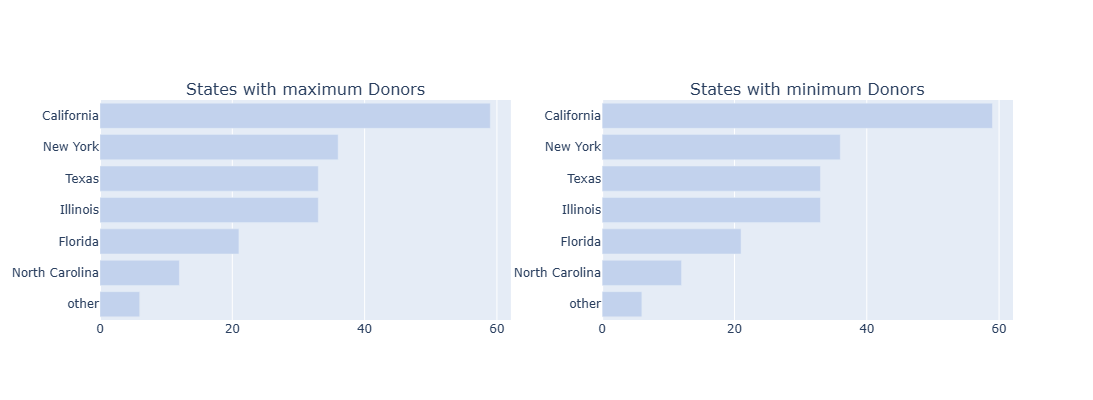

In [46]:
def bar_hor(df, col, title, color, w=None, h=None, lm=0, limit=100, return_trace=False, rev=False):
    cnt_srs = df[col].value_counts()
    yy = cnt_srs.head(limit).index[::-1] 
    xx = cnt_srs.head(limit).values[::-1] 
    if rev:
        yy = cnt_srs.tail(limit).index[::-1] 
        xx = cnt_srs.tail(limit).values[::-1] 
        
    
    trace = go.Bar(y=yy, x=xx, orientation = 'h', marker=dict(color=color))
    if return_trace:
        return trace 
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

def bar_hor_noagg(x, y, title, color, w=None, h=None, lm=0, limit=100, rt=False):
    trace = go.Bar(y=x, x=y, orientation = 'h', marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)


def bar_ver_noagg(x, y, title, color, w=None, h=None, lm=0, rt = False):
    trace = go.Bar(y=y, x=x, marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

    
trace1 = bar_hor(donors_df, 'Donor City', "Top Cities with maximum Donors", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace2 = bar_hor(donors_df, 'Donor State', "Top States with maximum Donors", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace4 = bar_hor(donors_df, 'Donor State', "Top States with maximum Donors", '#c2d2ed', 600, 400, 200, limit = 10, return_trace=True, rev=True)


fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors'])
# fig = tools.make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]], print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors', 'Cities with maximum Donors'])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace4, 1, 2);
# fig.append_trace(trace1, 2, 1);

fig['layout'].update(height=400, showlegend=False);
iplot(fig); 

### Interpretación de los Resultados

A partir del análisis exploratorio realizado mediante los mapas de calor y otras técnicas de visualización, es posible identificar relaciones importantes entre las variables del conjunto de datos.

Entre las principales observaciones se encuentran:

- Las variables con coeficientes de correlación cercanos a **1** presentan una **fuerte relación positiva**, lo que indica que ambas tienden a aumentar o disminuir de manera similar.

- Las variables con coeficientes cercanos a **-1** muestran una **fuerte relación negativa**, es decir, cuando una variable aumenta, la otra tiende a disminuir.

- Los valores próximos a **0** indican una **correlación débil o inexistente**, lo que sugiere que las variables no presentan una relación lineal significativa.

- Los mapas de calor permiten identificar rápidamente grupos de variables relacionadas, facilitando la detección de patrones y posibles redundancias dentro del conjunto de datos.

- En proyectos de Ciencia de Datos, este análisis resulta especialmente útil para detectar **multicolinealidad**, seleccionar variables relevantes y comprender la estructura del conjunto de datos antes de construir modelos predictivos.

---

## <a>Conjunto de Datos Ajustado para el Análisis</a>

En algunos casos, las variables pueden encontrarse en escalas muy diferentes, lo que dificulta su comparación directa. Por ello, antes de generar determinados mapas de calor, puede ser conveniente aplicar técnicas de normalización o estandarización que permitan comparar las variables bajo una misma escala.

Este proceso mejora la interpretación visual y facilita la identificación de patrones entre las diferentes características del conjunto de datos.

---

## <a id="2.3">2.3 Mapa de Calor de la Matriz de Correlación</a>

En esta sección construiremos la matriz de correlación entre las variables numéricas del conjunto de datos y la representaremos mediante un **Heatmap**. La intensidad del color mostrará el grado de asociación entre cada par de variables, permitiendo identificar relaciones fuertes, débiles o negativas de manera inmediata.

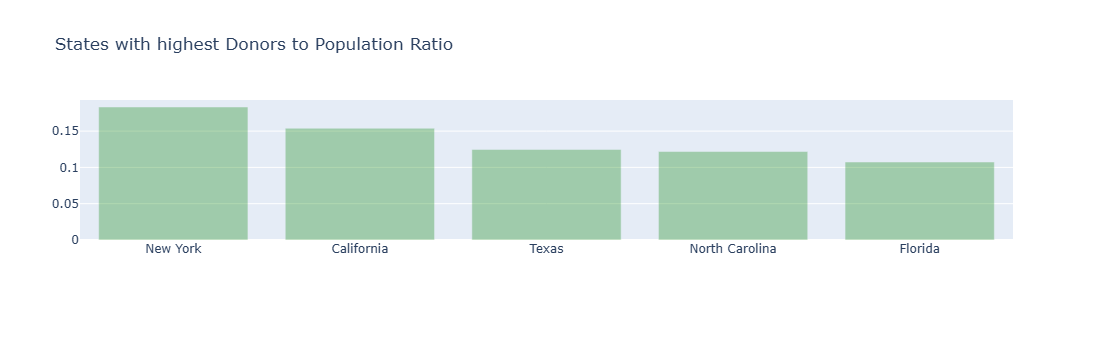

In [36]:
census_2013 = {'Mississippi': 2991207, 'Iowa': 3090416, 'Oklahoma': 3850568, 'Delaware': 925749, 'Minnesota': 5420380, 'Alaska': 735132, 'Illinois': 12882135, 'Arkansas': 2959373, 'New Mexico': 2085287, 'Indiana': 6570902, 'Maryland': 5928814, 'Louisiana': 4625470, 'Texas': 26448193, 'Wyoming': 582658, 'Arizona': 6626624, 'Wisconsin': 5742713, 'Michigan': 9895622, 'Kansas': 2893957, 'Utah': 2900872, 'Virginia': 8260405, 'Oregon': 3930065, 'Connecticut': 3596080, 'New York': 19651127, 'California': 38332521, 'Massachusetts': 6692824, 'West Virginia': 1854304, 'South Carolina': 4774839, 'New Hampshire': 1323459, 'Vermont': 626630, 'Georgia': 9992167, 'North Dakota': 723393, 'Pennsylvania': 12773801, 'Florida': 19552860, 'Hawaii': 1404054, 'Kentucky': 4395295, 'Rhode Island': 1051511, 'Nebraska': 1868516, 'Missouri': 6044171, 'Ohio': 11570808, 'Alabama': 4833722, 'South Dakota': 844877, 'Colorado': 5268367, 'Idaho': 1612136, 'New Jersey': 8899339, 'Washington': 6971406, 'North Carolina': 9848060, 'Tennessee': 6495978, 'Montana': 1015165, 'District of Columbia': 646449, 'Nevada': 2790136, 'Maine': 1328302}

donors_from_states = dict(donors_df['Donor State'].value_counts())

don_pop = {}
for state, don in donors_from_states.items():
    if state not in census_2013:
        continue
    don_pop[state]  = float(don)*100000/ census_2013[state]

import operator
don_pop = sorted(don_pop.items(), key=operator.itemgetter(1), reverse = True)
xx = [x[0] for x in (don_pop)][1:]
yy = [x[1] for x in (don_pop)][1:]

trace2 = go.Bar(
    x=xx,
    y=yy,
    name='Donors to Population',
    marker=dict(color='green'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'States with highest Donors to Population Ratio',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

### Interpretación del Análisis Ajustado por Población

Al considerar la relación entre el número de donantes y la población de cada estado, se obtienen conclusiones más precisas sobre la distribución real de los donantes en Estados Unidos.

Este enfoque permite normalizar los datos y evitar sesgos asociados únicamente al tamaño poblacional de cada estado.

Entre los principales hallazgos se observa que:

- **South Carolina**, **Massachusetts** y **Connecticut** presentan la mayor proporción de donantes por cada 100,000 habitantes. Esto indica una alta participación relativa de la población en actividades de donación.
  - South Carolina: aproximadamente **985 donantes por cada 100K habitantes**
  - Massachusetts: aproximadamente **907 donantes por cada 100K habitantes**
  - Connecticut: aproximadamente **878 donantes por cada 100K habitantes**

- En contraste, estados como **Wyoming**, **Nebraska** y **New Mexico** presentan los valores más bajos en términos de donantes ajustados por población:
  - Wyoming: ~285 donantes por cada 100K habitantes
  - Nebraska: ~335 donantes por cada 100K habitantes
  - New Mexico: ~363 donantes por cada 100K habitantes

- Aunque **Texas** es uno de los estados con mayor número absoluto de donantes, su proporción ajustada por población es relativamente menor (**~508 donantes por cada 100K habitantes**), lo que sugiere que su gran volumen total se debe principalmente a su tamaño poblacional.

Este tipo de normalización es fundamental en el análisis de datos, ya que permite comparar regiones de manera más justa y evita interpretaciones sesgadas basadas únicamente en valores absolutos.

---

## <a id="2.4">2.4 Visualización de la Ubicación de los Donantes</a>

En esta sección se explorará la distribución geográfica de los donantes utilizando técnicas de visualización, con el objetivo de identificar patrones espaciales y concentración de actividad en diferentes regiones del país.

## <a id="2.4.1">2.4.1 Ubicación de los Donantes en California</a>

In [47]:
calcit = StringIO(u"""Name,Latitude,Longitude,Total Donors,Color,Size
Los Angeles,34.052233,-118.243686,"17,922.000000",#0061ff,10
San Francisco,37.774931,-122.419417,"16,553.000000",#0061ff,10
San Diego,32.715328,-117.157256,"9,072.000000",#0061ff,10
San Jose,37.339386,-121.894956,"7,674.000000",#0061ff,10
Oakland,37.804364,-122.271114,"6,783.000000",#0061ff,10
Sacramento,38.581572,-121.494400,"4,701.000000",#0061ff,10
Bakersfield,35.373292,-119.018711,"3,758.000000",#0061ff,10
Long Beach,33.768322,-118.195617,"3,120.000000",#0061ff,10
Berkeley,37.871592,-122.272747,"2,898.000000",#0061ff,10
Irvine,33.683947,-117.794694,"2,765.000000",#0061ff,10
Fremont,37.548269,-121.988572,"2,716.000000",#0061ff,10
Walnut Creek,37.910078,-122.065183,"2,255.000000",#0061ff,10
Huntington Beach,33.660297,-117.999225,"2,185.000000",#0061ff,10
Murrieta,33.553914,-117.213922,"1,982.000000",#0061ff,10
Pleasanton,37.662431,-121.874678,"1,970.000000",#0061ff,10
Torrance,33.83585,-118.340628,"1,957.000000",#0061ff,10
San Mateo,37.562992,-122.325525,"1,956.000000",#0061ff,10
Santa Monica,34.019453,-118.491192,"1,780.000000",#0061ff,10
Livermore,37.681875,-121.768008,"1,776.000000",#0061ff,10
Santa Rosa,38.440467,-122.714431,"1,752.000000",#0061ff,10
Concord,37.977978,-122.031072,"1,623.000000",#0061ff,10
Alameda,37.765206,-122.241636,"1,548.000000",#0061ff,10
Fresno,36.746842,-119.772586,"1,543.000000",#0061ff,10
San Ramon,37.779928,-121.978014,"1,533.000000",#0061ff,10
Anaheim,33.835292,-117.914503,"1,475.000000",#0061ff,10
Pasadena,34.147786,-118.144517,"1,429.000000",#0061ff,10
Glendale,34.142508,-118.255075,"1,427.000000",#0061ff,10
Riverside,33.95335,-117.396156,"1,425.000000",#0061ff,10
Sunnyvale,37.368831,-122.036350,"1,406.000000",#0061ff,10
Chula Vista,32.640053,-117.084197,"1,398.000000",#0061ff,10
Mountain View,37.386053,-122.083850,"1,398.000000",#0061ff,10
Elk Grove,38.4088,-121.371617,"1,397.000000",#0061ff,10
Santa Clarita,34.391664,-118.542586,"1,382.000000",#0061ff,10
Burbank,34.180839,-118.308967,"1,357.000000",#0061ff,10
Redwood City,37.485214,-122.236356,"1,323.000000",#0061ff,10
Chico,39.728494,-121.837478,"1,322.000000",#0061ff,10
Whittier,33.979178,-118.032844,"1,280.000000",#0061ff,10
Corona,33.875294,-117.566439,"1,239.000000",#0061ff,10
Santa Clara,37.354108,-121.955236,"1,233.000000",#0061ff,10
Orange,33.787794,-117.853111,"1,229.000000",#0061ff,10
Palo Alto,37.441883,-122.143019,"1,219.000000",#0061ff,10
Hayward,37.668819,-122.080797,"1,162.000000",#0061ff,10
Oceanside,33.195869,-117.379483,"1,157.000000",#0061ff,10
Fullerton,33.870292,-117.925339,"1,151.000000",#0061ff,10
San Rafael,37.973536,-122.531086,"1,136.000000",#0061ff,10
Folsom,38.677958,-121.176058,"1,125.000000",#0061ff,10
Simi Valley,34.269447,-118.781483,"1,069.000000",#0061ff,10
Escondido,33.119208,-117.086422,"1,062.000000",#0061ff,10
Santa Ana,33.745572,-117.867833,"1,054.000000",#0061ff,10
Redondo Beach,33.849183,-118.388408,"1,048.000000",#34ef6c,8
Stockton,37.957703,-121.290781,"1,041.000000",#34ef6c,8
Santa Cruz,36.974117,-122.030797,"1,029.000000",#34ef6c,8
Culver City,34.021122,-118.396467,"1,019.000000",#34ef6c,8
Salinas,36.677736,-121.655500,"1,017.000000",#34ef6c,8
Martinez,38.019367,-122.134133,975.000000,#34ef6c,8
Santa Barbara,34.420831,-119.698189,936.000000,#34ef6c,8
San Leandro,37.724931,-122.156078,929.000000,#34ef6c,8
Ventura,34.274639,-119.229006,922.000000,#34ef6c,8
Roseville,38.752122,-121.288006,888.000000,#34ef6c,8
Yorba Linda,33.888625,-117.813111,888.000000,#34ef6c,8
Costa Mesa,33.641133,-117.918669,887.000000,#34ef6c,8
San Marcos,33.143372,-117.166144,866.000000,#34ef6c,8
Brentwood,34.057361,-118.480511,853.000000,#34ef6c,8
South San Francisco,37.654656,-122.407750,841.000000,#34ef6c,8
Modesto,37.639097,-120.996878,837.000000,#34ef6c,8
Temecula,33.493639,-117.148364,837.000000,#34ef6c,8
Novato,38.107419,-122.569703,831.000000,#34ef6c,8
Carlsbad,33.158092,-117.350594,822.000000,#34ef6c,8
Mission Viejo,33.600022,-117.671994,817.000000,#34ef6c,8
Brea,33.916681,-117.900061,802.000000,#34ef6c,8
Garden Grove,33.773906,-117.941447,792.000000,#34ef6c,8
Dublin,37.702153,-121.935792,784.000000,#34ef6c,8
El Cajon,32.794772,-116.962528,783.000000,#34ef6c,8
Menlo Park,37.453828,-122.182186,768.000000,#34ef6c,8
Fairfield,38.249358,-122.039967,751.000000,#34ef6c,8
Pleasant Hill,37.947978,-122.060797,725.000000,#34ef6c,8
Napa,38.297539,-122.286864,711.000000,#34ef6c,8
Richmond,37.935758,-122.347750,707.000000,#34ef6c,8
Los Altos,33.796331,-118.118119,703.000000,#34ef6c,8
Daly City,37.687925,-122.470208,702.000000,#34ef6c,8
West Covina,34.068622,-117.938953,688.000000,#34ef6c,8
Lafayette,37.885758,-122.118019,660.000000,#34ef6c,8
La Mesa,32.767828,-117.023083,649.000000,#34ef6c,8
Milpitas,37.428272,-121.906625,649.000000,#34ef6c,8
Carson,33.831406,-118.282017,647.000000,#34ef6c,8
Camarillo,34.216394,-119.037603,643.000000,#34ef6c,8
Petaluma,38.232417,-122.636653,629.000000,#34ef6c,8
Newport Beach,33.618911,-117.928947,626.000000,#34ef6c,8
Pacifica,37.613825,-122.486919,619.000000,#34ef6c,8
Gilroy,37.005783,-121.568275,618.000000,#34ef6c,8
Encinitas,33.036986,-117.291983,607.000000,#34ef6c,8
El Segundo,33.919181,-118.416464,595.000000,#34ef6c,8
Downey,33.940014,-118.132569,592.000000,#34ef6c,8
Rancho Palos Verdes,33.744461,-118.387017,592.000000,#34ef6c,8
San Clemente,33.426972,-117.611992,589.000000,#34ef6c,8
Vacaville,38.356578,-121.987744,584.000000,#34ef6c,8
Chino Hills,33.989819,-117.732586,583.000000,#34ef6c,8
Campbell,37.287164,-121.949958,580.000000,#34ef6c,8
Mill Valley,37.906036,-122.544975,578.000000,#34ef6c,8
El Cerrito,37.916133,-122.310764,576.000000,#f2ae93,6
Emeryville,37.831317,-122.285247,572.000000,#f2ae93,6
Thousand Oaks,34.107231,-118.057847,572.000000,#f2ae93,6
Burlingame,37.584103,-122.366083,570.000000,#f2ae93,6
Antioch,38.004922,-121.805789,568.000000,#f2ae93,6
Beverly Hills,34.073619,-118.400356,568.000000,#f2ae93,6
Lakewood,33.853628,-118.133956,560.000000,#f2ae93,6
Manhattan Beach,33.884736,-118.410908,557.000000,#f2ae93,6
Lancaster,34.686786,-118.154164,551.000000,#f2ae93,6
Oxnard,34.197506,-119.177053,539.000000,#f2ae93,6
San Carlos,37.507158,-122.260522,527.000000,#f2ae93,6
Rocklin,38.790733,-121.235783,526.000000,#f2ae93,6
Placentia,33.872236,-117.870336,520.000000,#f2ae93,6
Cupertino,37.322997,-122.032183,516.000000,#f2ae93,6
Tustin,33.74585,-117.826167,508.000000,#f2ae93,6
Hermosa Beach,33.862236,-118.399519,507.000000,#f2ae93,6
Rancho Cordova,38.589072,-121.302728,501.000000,#f2ae93,6
Fountain Valley,33.709186,-117.953669,498.000000,#f2ae93,6
Cypress,37.320531,-121.962242,497.000000,#f2ae93,6
Union City,37.593392,-122.043831,494.000000,#f2ae93,6
Morgan Hill,37.1305,-121.654389,488.000000,#f2ae93,6
Vallejo,38.104086,-122.256636,485.000000,#f2ae93,6
Alhambra,34.095286,-118.127014,474.000000,#f2ae93,6
Lake Forest,33.646967,-117.689217,465.000000,#f2ae93,6
Rancho Cucamonga,34.1064,-117.593108,463.000000,#f2ae93,6
Vista,33.200036,-117.242536,463.000000,#f2ae93,6
Fontana,34.092233,-117.435047,459.000000,#f2ae93,6
Moreno Valley,33.942467,-117.229672,455.000000,#f2ae93,6
Hawthorne,33.916403,-118.352575,450.000000,#f2ae93,6
Covina,34.090008,-117.890339,443.000000,#f2ae93,6
San Luis Obispo,35.282753,-120.659617,434.000000,#f2ae93,6
Newark,37.529658,-122.040239,433.000000,#f2ae93,6
Inglewood,33.961681,-118.353131,432.000000,#f2ae93,6
Oakley,37.997422,-121.712453,430.000000,#f2ae93,6
Tracy,37.73965,-121.425222,428.000000,#f2ae93,6
Redding,40.586539,-122.391675,424.000000,#f2ae93,6
Glendora,34.136119,-117.865339,423.000000,#f2ae93,6
San Bruno,37.630489,-122.411083,423.000000,#f2ae93,6
Davis,38.544906,-121.740517,417.000000,#f2ae93,6
Westminster,33.751342,-117.993992,413.000000,#f2ae93,6
Pittsburg,38.027975,-121.884681,412.000000,#f2ae93,6
Palmdale,34.579433,-118.116461,408.000000,#f2ae93,6
Visalia,36.330228,-119.292058,406.000000,#f2ae93,6
Poway,32.962822,-117.035864,403.000000,#f2ae93,6
Santa Maria,34.953033,-120.435719,403.000000,#f2ae93,6
Upland,34.097511,-117.648389,396.000000,#f2ae93,6
Laguna Niguel,33.522525,-117.707553,393.000000,#f2ae93,6
La Mirada,33.917236,-118.012008,392.000000,#f2ae93,6
South Pasadena,34.116119,-118.150350,391.000000,#f2ae93,6
Cerritos,33.858347,-118.064786,383.000000,#f2ae93,6
Lodi,38.134147,-121.272219,380.000000,#f2ae93,6
Ontario,34.063344,-117.650889,380.000000,#bab7b6,4
Lincoln,38.891564,-121.293008,376.000000,#bab7b6,4
Buena Park,33.867514,-117.998117,375.000000,#bab7b6,4
Rancho Santa Margarita,33.640856,-117.603103,373.000000,#bab7b6,4
Santee,32.838383,-116.973917,373.000000,#bab7b6,4
Sonoma,38.291858,-122.458036,372.000000,#bab7b6,4
Monrovia,34.144428,-118.001947,371.000000,#bab7b6,4
Albany,37.886869,-122.297747,368.000000,#bab7b6,4
La Habra,33.931958,-117.946172,366.000000,#bab7b6,4
San Pablo,37.962147,-122.345525,366.000000,#bab7b6,4
Belmont,37.520214,-122.275800,364.000000,#bab7b6,4
Pomona,34.055228,-117.752306,364.000000,#bab7b6,4
Gardena,33.88835,-118.308961,363.000000,#bab7b6,4
Arcadia,34.139728,-118.035344,361.000000,#bab7b6,4
Clovis,36.825228,-119.702919,360.000000,#bab7b6,4
Orinda,37.877147,-122.179689,358.000000,#bab7b6,4
Manteca,37.797428,-121.216053,357.000000,#bab7b6,4
Citrus Heights,38.707125,-121.281061,355.000000,#bab7b6,4
Redlands,34.055569,-117.182539,353.000000,#bab7b6,4
Aliso Viejo,33.575,-117.725556,345.000000,#bab7b6,4
Eureka,40.802072,-124.163672,338.000000,#bab7b6,4
West Hollywood,34.090008,-118.361744,337.000000,#bab7b6,4
Auburn,38.896564,-121.076889,335.000000,#bab7b6,4
Saratoga,37.263833,-122.023014,331.000000,#bab7b6,4
Turlock,37.494658,-120.846594,327.000000,#bab7b6,4
Chino,34.012236,-117.688944,325.000000,#bab7b6,4
Diamond Bar,34.028622,-117.810336,324.000000,#bab7b6,4
South Gate,33.954736,-118.212017,319.000000,#bab7b6,4
San Bernardino,34.108344,-117.289764,318.000000,#bab7b6,4
Claremont,34.096675,-117.719778,316.000000,#bab7b6,4
Calabasas,34.138333,-118.660833,298.000000,#bab7b6,4
Los Alamitos,33.803072,-118.072564,297.000000,#bab7b6,4
Agoura Hills,34.153339,-118.761675,295.000000,#bab7b6,4
San Gabriel,34.096111,-118.105833,295.000000,#bab7b6,4
Paso Robles,35.632278,-120.664186,292.000000,#bab7b6,4
Norwalk,33.902236,-118.081733,286.000000,#bab7b6,4
Indio,33.720578,-116.215561,284.000000,#bab7b6,4
Moorpark,34.144897,-118.268742,284.000000,#bab7b6,4
Monterey,36.600239,-121.894675,275.000000,#bab7b6,4
Arroyo Grande,35.118586,-120.590725,274.000000,#bab7b6,4
San Dimas,34.106675,-117.806725,274.000000,#bab7b6,4
La Puente,34.020011,-117.949508,273.000000,#bab7b6,4
West Sacramento,38.580461,-121.530233,273.000000,#bab7b6,4
Rohnert Park,38.339636,-122.701097,269.000000,#bab7b6,4
Monterey Park,34.062511,-118.122847,266.000000,#bab7b6,4
Laguna Hills,33.599722,-117.699444,260.000000,#bab7b6,4
Watsonville,36.910231,-121.756894,259.000000,#bab7b6,4
Clayton,37.941033,-121.935792,256.000000,#bab7b6,4
Hemet,33.747519,-116.971967,256.000000,#bab7b6,4
La Verne,34.100842,-117.767836,255.000000,#bab7b6,4
Ukiah,39.150172,-123.207783,255.000000,#f477d7,2
Palm Desert,33.722244,-116.374456,251.000000,#f477d7,2
Atascadero,35.489417,-120.670725,241.000000,#f477d7,2
Menifee,33.678333,-117.166944,241.000000,#f477d7,2
Lompoc,34.63915,-120.457942,240.000000,#f477d7,2
Merced,37.302164,-120.482967,240.000000,#f477d7,2
Sebastopol,38.402136,-122.823881,237.000000,#f477d7,2
Lake Elsinore,33.668078,-117.327261,236.000000,#f477d7,2
Millbrae,37.598547,-122.387194,234.000000,#f477d7,2
Yuba City,39.140447,-121.616911,231.000000,#f477d7,2
Woodland,38.678517,-121.773297,228.000000,#f477d7,2
Bellflower,33.881683,-118.117011,227.000000,#f477d7,2
Grass Valley,39.219061,-121.061061,227.000000,#f477d7,2
Seal Beach,33.741406,-118.104786,227.000000,#f477d7,2
Walnut,34.020289,-117.865339,227.000000,#f477d7,2
Montebello,34.016506,-118.113753,225.000000,#f477d7,2
Yucaipa,34.033625,-117.043086,225.000000,#f477d7,2
Hanford,36.32745,-119.645683,224.000000,#f477d7,2
Goleta,34.435828,-119.827639,221.000000,#f477d7,2
Hesperia,34.426389,-117.300878,221.000000,#f477d7,2
Laguna Beach,33.542247,-117.783111,221.000000,#f477d7,2
Ridgecrest,35.622456,-117.670897,218.000000,#f477d7,2
Galt,38.254636,-121.299947,217.000000,#f477d7,2
Victorville,34.536108,-117.291158,217.000000,#f477d7,2
San Juan Capistrano,33.501692,-117.662550,209.000000,#f477d7,2
Atwater,37.347717,-120.609083,208.000000,#f477d7,2
Palm Springs,33.830297,-116.545292,208.000000,#f477d7,2
Azusa,34.133619,-117.907564,203.000000,#f477d7,2
Hercules,38.017144,-122.288581,202.000000,#f477d7,2
Sonora,37.984092,-120.382139,199.000000,#f477d7,2
Beaumont,33.929461,-116.977247,198.000000,#f477d7,2
Half Moon Bay,37.463553,-122.428586,197.000000,#f477d7,2
Hollister,36.852453,-121.401603,196.000000,#f477d7,2
Westlake Village,34.145839,-118.805647,194.000000,#f477d7,2
Pico Rivera,33.983069,-118.096736,190.000000,#f477d7,2
Pinole,38.004367,-122.298858,186.000000,#f477d7,2
Compton,33.89585,-118.220072,185.000000,#f477d7,2
Sausalito,37.859094,-122.485250,183.000000,#f477d7,2
La Quinta,33.646692,-116.310008,181.000000,#f477d7,2
Dana Point,33.466972,-117.698108,175.000000,#f477d7,2
Rialto,34.1064,-117.370325,172.000000,#f477d7,2
Perris,33.782519,-117.228647,171.000000,#f477d7,2
Arcata,40.866517,-124.082839,168.000000,#f477d7,2
Pacific Grove,36.617736,-121.916622,168.000000,#f477d7,2
Lomita,33.792239,-118.315072,167.000000,#f477d7,2
San Fernando,34.281947,-118.438972,165.000000,#f477d7,2
South Lake Tahoe,38.939925,-119.977186,163.000000,#f477d7,2
El Monte,34.068622,-118.027567,158.000000,#f477d7,2
Scotts Valley,37.051061,-122.014683,158.000000,#f477d7,2
Tehachapi,35.132189,-118.448975,157.000000,#f477d7,2
Baldwin Park,34.085286,-117.960897,156.000000,#f477d7,2
Marina,36.684403,-121.802172,155.000000,#f477d7,2
Rosemead,34.080564,-118.072847,155.000000,#f477d7,2
Placerville,38.729625,-120.798547,151.000000,#f477d7,2
Highland,34.128344,-117.208650,148.000000,#f477d7,2
Lawndale,33.887236,-118.352575,143.000000,#f477d7,2
Oroville,39.513775,-121.556358,142.000000,#f477d7,2
Seaside,33.819361,-118.366647,142.000000,#f477d7,2
Wildomar,33.598914,-117.280036,142.000000,#f477d7,2
Duarte,34.13945,-117.977286,141.000000,#f477d7,2
Huntington Park,33.981681,-118.225072,141.000000,#f477d7,2
Larkspur,37.934092,-122.535253,139.000000,#f477d7,2
Del Mar,32.959489,-117.265314,138.000000,#f477d7,2
Winters,38.524906,-121.970803,138.000000,#f477d7,2
Red Bluff,40.178489,-122.235831,137.000000,#f477d7,2
Cathedral City,33.779742,-116.465292,136.000000,#f9e84a,1
Ojai,34.44805,-119.242889,136.000000,#f9e84a,1
Coronado,32.685886,-117.183089,134.000000,#f9e84a,1
Lynwood,33.930292,-118.211461,134.000000,#f9e84a,1
Temple City,34.107231,-118.057847,132.000000,#f9e84a,1
Bell,33.977514,-118.187017,124.000000,#f9e84a,1
Sierra Madre,34.161672,-118.052847,119.000000,#f9e84a,1
Nevada City,39.261561,-121.016058,118.000000,#f9e84a,1
National City,32.678108,-117.099197,117.000000,#f9e84a,1
Ceres,37.594933,-120.957711,116.000000,#f9e84a,1
Solana Beach,32.991156,-117.271147,115.000000,#f9e84a,1
La Palma,33.846403,-118.046731,114.000000,#f9e84a,1
Healdsburg,38.610467,-122.869161,110.000000,#f9e84a,1
Ripon,37.739453,-121.135414,109.000000,#f9e84a,1
Crescent City,41.755947,-124.201747,108.000000,#f9e84a,1
Malibu,34.005008,-118.810172,108.000000,#f9e84a,1
Patterson,37.4716,-121.129656,107.000000,#f9e84a,1
Maywood,33.986681,-118.185350,105.000000,#f9e84a,1
Suisun City,38.238247,-122.040244,105.000000,#f9e84a,1
Dixon,38.445464,-121.823297,104.000000,#f9e84a,1
Fort Bragg,39.445722,-123.805292,103.000000,#f9e84a,1
Oakdale,37.766594,-120.847153,103.000000,#f9e84a,1
American Canyon,38.174917,-122.260803,100.000000,#f9e84a,1
Lemon Grove,32.742553,-117.031417,97.000000,#f9e84a,1
Carpinteria,34.398883,-119.518456,96.000000,#f9e84a,1
Lemoore,36.300783,-119.782911,96.000000,#f9e84a,1
San Jacinto,33.783908,-116.958636,95.000000,#f9e84a,1
San Marino,34.121397,-118.106458,95.000000,#f9e84a,1
Paramount,33.889461,-118.159792,94.000000,#f9e84a,1
Tulare,36.207728,-119.347339,93.000000,#f9e84a,1
Twentynine Palms,34.135558,-116.054169,92.000000,#f9e84a,1
Shafter,35.500514,-119.271775,91.000000,#f9e84a,1
Norco,33.931125,-117.548661,89.000000,#f9e84a,1
Capitola,36.975228,-121.953292,88.000000,#f9e84a,1
Rio Vista,38.15575,-121.691344,88.000000,#f9e84a,1
Colton,34.073903,-117.313656,86.000000,#f9e84a,1
Brisbane,37.680767,-122.399972,85.000000,#f9e84a,1
Taft,35.142467,-119.456508,85.000000,#f9e84a,1
Imperial Beach,32.583944,-117.113086,84.000000,#f9e84a,1
Kingsburg,36.513839,-119.554017,84.000000,#f9e84a,1
Morro Bay,35.365808,-120.849900,83.000000,#f9e84a,1
Santa Fe Springs,33.947236,-118.085344,83.000000,#f9e84a,1
Rancho Mirage,33.739744,-116.412789,78.000000,#f9e84a,1
Stanton,33.802517,-117.993117,78.000000,#f9e84a,1
Madera,36.961336,-120.060717,77.000000,#f9e84a,1
Los Banos,37.058278,-120.849914,76.000000,#f9e84a,1
Riverbank,37.736039,-120.935489,76.000000,#f9e84a,1
Gridley,39.363778,-121.693583,75.000000,#f9e84a,1
Pismo Beach,35.142753,-120.641283,74.000000,#f9e84a,1
Santa Paula,34.354167,-119.059269,74.000000,#f9e84a,1
Cotati,38.327778,-122.709167,73.000000,#f9e84a,1
Port Hueneme,34.180728,-119.208158,73.000000,#f9e84a,1
Selma,36.570783,-119.612075,73.000000,#f9e84a,1
Banning,33.925572,-116.876411,71.000000,#f9e84a,1
King City,36.212744,-121.126028,71.000000,#f9e84a,1
El Centro,32.792,-115.563050,69.000000,#f9e84a,1
Lakeport,39.04295,-122.915828,69.000000,#f9e84a,1
Willits,39.409608,-123.355567,68.000000,#f9e84a,1
Barstow,34.895797,-117.017283,67.000000,#f9e84a,1
Marysville,39.145725,-121.591356,67.000000,#f9e84a,1
Orland,39.747381,-122.196375,66.000000,#f9e84a,1
Grand Terrace,34.033903,-117.313653,63.000000,#f9e84a,1
Montclair,34.077511,-117.689778,63.000000,#f9e84a,1
Villa Park,33.814461,-117.813111,63.000000,#f9e84a,1
Artesia,33.865847,-118.083122,62.000000,#f9e84a,1
Desert Hot Springs,33.961125,-116.501678,61.000000,#f9e84a,1
Fortuna,40.598186,-124.157275,61.000000,#f9e84a,1
Grover Beach,35.121642,-120.621283,61.000000,#f9e84a,1
Loma Linda,34.048347,-117.261153,59.000000,#f9e84a,1
Dinuba,36.543283,-119.387067,58.000000,#f9e84a,1
South El Monte,34.051956,-118.046733,58.000000,#f9e84a,1
Porterville,36.065231,-119.016767,57.000000,#f9e84a,1
Lathrop,37.822706,-121.276611,56.000000,#f9e84a,1
Coalinga,36.139678,-120.360150,55.000000,#f9e84a,1
Fillmore,34.399164,-118.918153,54.000000,#f9e84a,1
Mount Shasta,41.410806,-122.194575,52.000000,#f9e84a,1
Anderson,40.448208,-122.297783,51.000000,#f9e84a,1
Cloverdale,38.805461,-123.017222,50.000000,#f9e84a,1
Exeter,36.296061,-119.142053,50.000000,#f9e84a,1
Wasco,35.594125,-119.340947,50.000000,#f9e84a,1
Reedley,36.596339,-119.450403,47.000000,#f9e84a,1
Sanger,36.708006,-119.555964,47.000000,#f9e84a,1
Adelanto,34.582769,-117.409214,45.000000,#f9e84a,1
Brawley,32.978658,-115.530267,43.000000,#f9e84a,1
Calimesa,34.003903,-117.061975,42.000000,#f9e84a,1
Hughson,37.602725,-120.866481,42.000000,#f9e84a,1
Imperial,32.847553,-115.569439,41.000000,#f9e84a,1
Soledad,32.991156,-117.271147,41.000000,#f9e84a,1
Weed,41.42265,-122.386128,40.000000,#f9e84a,1
Calexico,32.678947,-115.498883,37.000000,#f9e84a,1
Willows,39.524325,-122.193592,36.000000,#f9e84a,1
Big Bear Lake,34.243897,-116.911422,35.000000,#f9e84a,1
Delano,35.768842,-119.247053,34.000000,#f9e84a,1
Newman,37.313828,-121.020761,34.000000,#f9e84a,1
Colfax,39.100731,-120.953275,33.000000,#f9e84a,1
Escalon,37.797428,-120.996603,33.000000,#f9e84a,1
Jackson,38.348803,-120.774103,32.000000,#f9e84a,1
Bishop,37.363539,-118.395111,31.000000,#f9e84a,1
Coachella,33.6803,-116.173894,31.000000,#f9e84a,1
Holtville,32.811161,-115.380264,31.000000,#f9e84a,1
Indian Wells,33.717631,-116.340756,31.000000,#f9e84a,1
San Juan Bautista,36.845511,-121.537997,31.000000,#f9e84a,1
Arvin,35.2018,-118.833106,30.000000,#f9e84a,1
Kerman,36.723558,-120.059878,30.000000,#f9e84a,1
Colusa,39.214333,-122.009417,27.000000,#f9e84a,1
Greenfield,36.3208,-121.243814,27.000000,#f9e84a,1
Waterford,37.641319,-120.760483,26.000000,#f9e84a,1
Ferndale,40.576242,-124.263944,25.000000,#f9e84a,1
Susanville,40.416283,-120.653006,25.000000,#f9e84a,1
Buellton,34.613597,-120.192650,24.000000,#f9e84a,1
Calistoga,38.578797,-122.579706,24.000000,#f9e84a,1
Clearlake,38.958231,-122.626372,24.000000,#f9e84a,1
Shasta Lake,40.680428,-122.370842,24.000000,#f9e84a,1
Yreka,41.735419,-122.634472,23.000000,#f9e84a,1
Biggs,39.412389,-121.712750,22.000000,#f9e84a,1
Chowchilla,37.123,-120.260175,22.000000,#f9e84a,1
Live Oak,36.983561,-121.980517,22.000000,#f9e84a,1
McFarland,35.678011,-119.229275,22.000000,#f9e84a,1
Fowler,36.630506,-119.678469,21.000000,#f9e84a,1
Gonzales,36.506628,-121.444381,21.000000,#f9e84a,1
Solvang,34.595819,-120.137647,21.000000,#f9e84a,1
Angels Camp,38.067783,-120.538531,20.000000,#f9e84a,1
Gustine,37.257717,-120.998814,20.000000,#f9e84a,1
Sutter Creek,38.392967,-120.802436,20.000000,#f9e84a,1
Wheatland,39.009894,-121.423014,20.000000,#f9e84a,1
Hawaiian Gardens,33.831403,-118.072842,19.000000,#f9e84a,1
Lindsay,36.203006,-119.088161,19.000000,#f9e84a,1
Livingston,37.386883,-120.723533,19.000000,#f9e84a,1
California City,35.1258,-117.985903,18.000000,#f9e84a,1
Corning,39.927658,-122.179156,18.000000,#f9e84a,1
Trinidad,41.059292,-124.143125,18.000000,#f9e84a,1
Ione,38.352692,-120.932717,17.000000,#f9e84a,1
Dunsmuir,41.208208,-122.271953,16.000000,#f9e84a,1
Tulelake,41.955989,-121.477492,15.000000,#f9e84a,1
Firebaugh,36.858839,-120.456008,13.000000,#f9e84a,1
Woodlake,36.413561,-119.098717,13.000000,#f9e84a,1
Blue Lake,40.882908,-123.983950,12.000000,#f9e84a,1
Blythe,33.617233,-114.589175,12.000000,#f9e84a,1
Avalon,33.342819,-118.328228,11.000000,#f9e84a,1
Montague,41.728197,-122.527800,11.000000,#f9e84a,1
Williams,39.154614,-122.149419,11.000000,#f9e84a,1
Alturas,41.487114,-120.542456,10.000000,#f9e84a,1
Corcoran,37.977978,-122.031072,9.000000,#f9e84a,1
Isleton,38.161861,-121.611622,9.000000,#f9e84a,1
Piedmont,37.824372,-122.231636,9.000000,#f9e84a,1
Rio Dell,40.4993,-124.106436,9.000000,#f9e84a,1
Huron,36.202731,-120.102917,8.000000,#f9e84a,1
Point Arena,38.908797,-123.693072,8.000000,#f9e84a,1
Dorris,41.967369,-121.918061,7.000000,#f9e84a,1
Dos Palos,36.986058,-120.626572,7.000000,#f9e84a,1
Etna,41.456806,-122.894756,6.000000,#f9e84a,1
Guadalupe,34.971644,-120.571836,6.000000,#f9e84a,1
Needles,34.848061,-114.614133,6.000000,#f9e84a,1
Plymouth,38.481853,-120.844658,5.000000,#f9e84a,1
Avenal,36.004122,-120.129028,4.000000,#f9e84a,1
Fort Jones,41.663864,-124.252892,4.000000,#f9e84a,1
Portola,39.810458,-120.469103,4.000000,#f9e84a,1
Calipatria,33.125597,-115.514153,3.000000,#f9e84a,1
Farmersville,36.297728,-119.206778,3.000000,#f9e84a,1
Loyalton,39.676294,-120.241039,3.000000,#f9e84a,1
Maricopa,35.058858,-119.400950,2.000000,#f9e84a,1
Parlier,36.611617,-119.527072,2.000000,#f9e84a,1
Bell Gardens,33.965292,-118.151458,1.000000,#f9e84a,1
Orange Cove,36.624394,-119.313731,1.000000,#f9e84a,1
San Joaquin,36.606617,-120.189044,1.000000,#f9e84a,1
Westmorland,33.037267,-115.621383,1.000000,#f9e84a,1""")



cities = pd.read_csv(calcit)
cities = cities.dropna()

# map_osm = folium.Map(location=[36.611617,-119.527072], zoom_start=5)

# for i, row in cities.iterrows():
#     folium.CircleMarker([row['Latitude'], row['Longitude']],
#                         radius=row['Size'],
#                         color=row['Color'],
#                         fill_color=row['Color'],
#                        ).add_to(map_osm)



map_osm2 = folium.Map([36.611617,-119.527072], zoom_start=6,tiles='cartodbdark_matter')
ziparr = []
for i, row in cities.iterrows():
    ziparr.append([row['Latitude'],row['Longitude'], float(row['Total Donors'].replace(",",""))])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))
map_osm2


NameError: name 'folium' is not defined

### Principales ubicaciones con mayor densidad de donantes

Las siguientes ciudades concentran la mayor cantidad de donantes dentro del estado de California, lo que refleja una fuerte actividad de participación en proyectos educativos en estas áreas urbanas:

- **Los Ángeles:** 17,922 donantes  
- **San Francisco:** 16,553 donantes  
- **San Diego:** 9,072 donantes  
- **San José:** 7,674 donantes  
- **Oakland:** 6,783 donantes  

Estas ciudades representan los principales centros urbanos donde se observa una mayor concentración de donantes, lo cual es consistente con la distribución poblacional y la actividad educativa del estado.

---

## <a id="2.4.2">2.4.2 Ubicación de los Donantes en Florida</a>

In [38]:
c = pd.read_csv('../input/cities/zip_codes_states.csv')
c = c.dropna()

fldf = c[c['state'] == 'FL'][['city', 'latitude', 'longitude']]

fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
t = donors_df[donors_df['Donor State'] == 'Florida']['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([29.813456, -82.472049], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))

FileNotFoundError: [Errno 2] No such file or directory: '../input/cities/zip_codes_states.csv'

### Distribución de donantes en Florida

La región conocida como el **tri-county area** de Florida (Palm Beach, Miami-Dade y Broward) concentra una alta densidad de donantes, lo que indica una fuerte participación en proyectos educativos dentro de estas zonas urbanas.

Además, la ciudad de **Tampa**, considerada uno de los principales centros del estado, también presenta un número significativo de donantes. Incluso áreas más alejadas como **Key West**, en el extremo sur de Florida, registran actividad de donación, aunque en menor proporción.

Las principales ciudades por número de donantes son:

- **Miami:** 9,309  
- **Tampa:** 6,016  
- **Orlando:** 5,658  
- **Jacksonville:** 4,598  
- **Fort Lauderdale:** 4,311  
- **West Palm Beach:** 2,400  

Estos resultados muestran una clara concentración de donantes en las principales áreas metropolitanas del estado.

---

## <a id="2.4.3">2.4.3 Distribución de los Donantes en Nueva York</a>

In [39]:
fldf = c[c['state'] == 'NY'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'New York']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([42.315975, -74.065515], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))

NameError: name 'c' is not defined

### Distribución de donantes en Nueva York

La mayor parte de los donantes en el estado de Nueva York se concentran en la ciudad de **Nueva York**, lo cual es consistente con su alta densidad poblacional y relevancia urbana.

Las principales ciudades por número de donantes son:

- **New York:** 26,820  
- **Brooklyn:** 21,715  
- **Staten Island:** 4,516  
- **Bronx:** 4,455  
- **Buffalo:** 2,232  

Estos datos muestran una fuerte concentración en el área metropolitana de Nueva York, donde se observa la mayor actividad de donaciones del estado.

---

## <a id="2.4.4">2.4.4 Distribución de los Donantes en Texas</a>

In [40]:
fldf = c[c['state'] == 'TX'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'Texas']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([31.884540, -97.077218], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))

NameError: name 'c' is not defined

### Distribución de donantes en Texas

En el estado de Texas, los donantes se concentran principalmente en las grandes áreas metropolitanas, lo cual refleja la relación entre densidad poblacional y actividad de donación.

Las ciudades con mayor número de donantes son:

- **Houston:** 15,404  
- **Austin:** 9,958  
- **Dallas:** 7,818  
- **San Antonio:** 6,465  
- **Fort Worth:** 4,350  

Estos resultados muestran que las principales ciudades urbanas del estado concentran la mayor parte de la actividad de donación.

---

## <a id="2.5">2.5 Distribución general de los donantes</a>

In [41]:
fldf = c[['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([39.3714557,-94.3541242], zoom_start=3.5,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=10))


NameError: name 'c' is not defined

Aunque el mayor número absoluto de donantes proviene del estado de **California**, ubicado en la costa oeste de Estados Unidos, se observa que la región de la **costa este** presenta una mayor densidad de donantes en comparación relativa.

Esto sugiere una distribución más concentrada en estados del este, donde la participación por área geográfica es más intensa. Adicionalmente, se identifica presencia de donantes en estados menos poblados como **Hawaii** y **Alaska**, lo que indica una cobertura amplia a nivel nacional.

En conjunto, estos resultados muestran que la actividad de donación no se limita a los principales centros urbanos, sino que está distribuida en distintas regiones del país con diferentes niveles de intensidad.

---

## <a id="2.6">2.6 Número de Docentes y Donantes No Docentes por Estado</a>

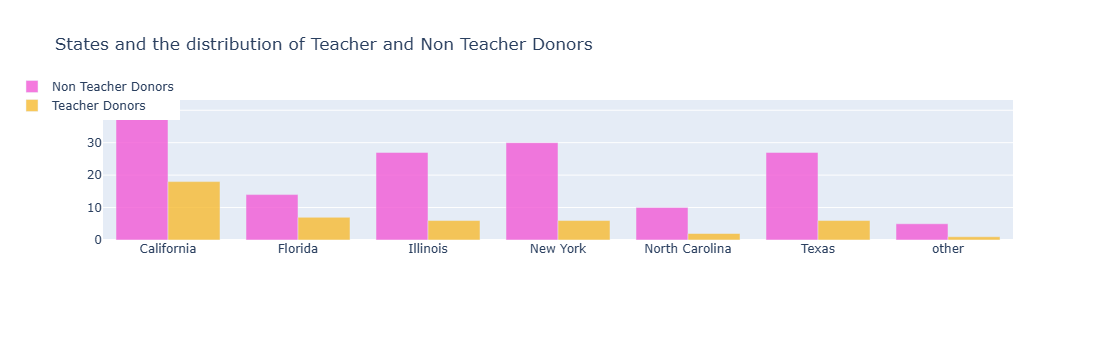

In [42]:
# which city and state has maximum teacher donors 
tempdf = donors_df.groupby(['Donor State', 'Donor Is Teacher']).agg({'Donor Is Teacher' : 'count' }).rename(columns={'Donor Is Teacher' : 'Teacher Donor Counts'}).reset_index()

no_df = tempdf[tempdf['Donor Is Teacher']=='No']
no_x = no_df['Donor State']
no_y = no_df['Teacher Donor Counts']
yes_df = tempdf[tempdf['Donor Is Teacher']=='Yes']
yes_x = yes_df['Donor State']
yes_y = yes_df['Teacher Donor Counts']

trace1 = go.Bar(
    x=no_x,
    y=no_y,
    name='Non Teacher Donors',
    marker=dict(color='#f259d6'),
    opacity=0.8
)
trace2 = go.Bar(
    x=yes_x,
    y=yes_y,
    name='Teacher Donors',
    marker=dict(color='#f7bb31'),
    opacity=0.8
)

data = [trace1, trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'States and the distribution of Teacher and Non Teacher Donors',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

Se observa que el número de **donantes que son docentes (teacher donors)** es relativamente bajo en comparación con el total de donantes en todos los estados analizados.

Un caso particular es el registro asociado a **“others”**, el cual presenta el mayor número de donantes docentes, con aproximadamente **28,000 registros**. Esto sugiere que esta categoría puede agrupar donantes que no están asignados a un estado específico o que provienen de ubicaciones fuera del sistema de clasificación principal.

---

## <a id="3">3. Exploración de las Donaciones</a>

El archivo de **donaciones** contiene información detallada sobre las contribuciones realizadas por los donantes. Entre las variables más importantes se incluyen:

- Monto total donado  
- Secuencia del carrito de donación  
- Fecha de la donación  
- Identificador del proyecto  
- Identificador del donante  

Este conjunto de datos permite analizar el comportamiento de las donaciones, patrones temporales y la relación entre donantes y proyectos financiados.

---

## <a id="3.1">3.1 Vista general de las donaciones</a>

Se observa que el número de **donantes que son docentes (teacher donors)** es relativamente bajo en comparación con el total de donantes en todos los estados analizados.

Un caso particular es el registro asociado a **“others”**, el cual presenta el mayor número de donantes docentes, con aproximadamente **28,000 registros**. Esto sugiere que esta categoría puede agrupar donantes que no están asignados a un estado específico o que provienen de ubicaciones fuera del sistema de clasificación principal.

---

## <a id="3">3. Exploración de las Donaciones</a>

El archivo de **donaciones** contiene información detallada sobre las contribuciones realizadas por los donantes. Entre las variables más importantes se incluyen:

- Monto total donado  
- Secuencia del carrito de donación  
- Fecha de la donación  
- Identificador del proyecto  
- Identificador del donante  

Este conjunto de datos permite analizar el comportamiento de las donaciones, patrones temporales y la relación entre donantes y proyectos financiados.

---

## <a id="3.1">3.1 Vista general de las donaciones</a>

In [ ]:
donations_df[['Donation ID', 'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Project ID', 'Donor ID']].head(3)
# donations_df.columns

# len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 20000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 10000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] < 1])
# np.mean(donations_df['Donation Amount'])

Se ha registrado un total de **4,687,884 donaciones** hasta abril de 2018 en la plataforma DonorsChoose. El monto máximo donado alcanza los **USD 60,000**, registrado en el año 2013.

Al analizar la distribución de las donaciones, se observa que:

- Solo **6 donaciones** superan los **USD 20,000**  
- Únicamente **61 pagos** son mayores a **USD 10,000**  
- Aproximadamente el **83% de las donaciones** son menores a **USD 100**  
- Existen **350 pagos menores a USD 1**, los cuales, aunque pequeños, contribuyen al financiamiento general de proyectos  

En total, la plataforma ha recaudado aproximadamente **USD 284,408,243**, con una donación promedio cercana a **USD 60**.

Estos resultados muestran una fuerte concentración de donaciones en montos pequeños, lo cual indica una base amplia de contribuyentes con aportes moderados.

En las siguientes secciones se analizará la relación entre donantes y proyectos financiados, con el objetivo de identificar patrones relevantes en la asignación de recursos.

---

## <a id="3.2">3.2 Proyectos y sus Donaciones</a>

En esta sección se identificarán los proyectos más relevantes en función de diferentes métricas de financiamiento:

- **3.2.1** Proyectos con mayor número de donantes  
- **3.2.2** Proyectos con mayor monto total financiado  
- **3.2.3** Proyectos con mayor monto promedio por donante  
- **3.2.4** Proyectos con mayor donación individual registrada  

In [ ]:
# Which Projects Had the maximum Donations 

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Project ID' : "Total Donations", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']

tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pa"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']
tr1 = bar_ver_noagg(x, y, 'Total Donations', '#43ef4b', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pb"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Average Donations', '#7fef84', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Project ID']
x = ["Pc"+str(i+1) for i in range(len(x))]
y = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations (Min: 10 Donations)', '#a5d1a7', lm=None, rt=True)

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Project ID' : "Total Donations", 'Donation Amount' : "Maximum Donations"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Maximum Donations'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pd"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donations']
tr4 = bar_ver_noagg(x, y, 'Maximum Donations', '#c0d1c1', lm=None, rt=True)



fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Amount Per Donor (Min 10 Donations)', 'Maximum Single Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Top Projects and their - Total Donations, Total Amount, Amount Per Donor, Maximum Single Amount');
iplot(fig); 

### Proyectos con mayor actividad de donaciones

En el análisis histórico de DonorsChoose, los proyectos presentan una gran variabilidad en el número de donaciones recibidas, desde proyectos con una sola contribución hasta iniciativas con cientos de aportes.

El número máximo de donaciones registradas en un solo proyecto es de **863 donaciones**, correspondiente al proyecto:

- **"Vallecito StandUpKids Pilot Standing School!"**

Este proyecto fue liderado por un docente y logró recaudar un total de **USD 108,248.30**, alcanzando su financiamiento completo el **26 de agosto de 2015**.

Además, existen otros proyectos con un alto nivel de participación, superando las **600 donaciones**, lo que refleja un fuerte interés de la comunidad en determinadas iniciativas educativas.

---

Un caso destacado ocurrió en noviembre de 2016 con el proyecto:

- **"Varsity and After-School Fencing Teams in NYC"**

Este proyecto recibió únicamente **18 donaciones**, pero alcanzó un promedio de **USD 1,850 por donante**, el valor más alto registrado en promedio por contribuyente.

---

Otro caso relevante es el proyecto:

- **"Learning to Play While Playing to Learn!"**

En este caso se registró la **donación individual más alta en la historia de la plataforma**, con un aporte de **USD 60,000**.

---

## <a id="3.3">3.3 ¿Quiénes son los principales donantes?</a>

En esta sección se analizarán los donantes más relevantes de la plataforma en función de diferentes métricas:

- **3.3.1** Donantes con mayor número de contribuciones  
- **3.3.2** Donantes con mayor monto total donado  
- **3.3.3** Donantes con mayor promedio de donación  
- **3.3.4** Donantes con la mayor donación individual registrada  

In [ ]:
# Which Projects Had the maximum Donations 

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Donor ID' : "Total Donations", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']

tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']
tr1 = bar_ver_noagg(x, y, 'Total Donations', '#d141ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Average Donations', '#db85ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations', '#d5b1db', lm=None, rt=True)

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Donor ID' : "Total Donations", 'Donation Amount' : "Maximum Donations"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Maximum Donations'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donations']
tr4 = bar_ver_noagg(x, y, 'Maximum Donations', '#ccbece', lm=None, rt=True)

fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Donated Amount', 'Maximum Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Top Donors and their Top Contributions');
iplot(fig); 

### Donantes más generosos

En el análisis de los donantes más activos de la plataforma se identifican algunos casos particularmente destacados por su volumen y nivel de contribución.

- Un donante no docente de **Manhattan Beach, California**, ha realizado más de **18,000 donaciones**, convirtiéndose en uno de los usuarios más activos de la plataforma.

- Otro donante no docente del estado de **Nueva York** ha contribuido con un total aproximado de **USD 1.8 millones**, distribuidos en cerca de **10,513 donaciones**.

- El mayor pago individual registrado, de **USD 60,000**, destinado al proyecto *"Learning to Play while Playing to Learn"*, fue realizado por un donante de **Anahola, Hawaii**. Este mismo donante ha realizado un total de **223 donaciones**.

Estos casos reflejan la presencia de donantes altamente comprometidos, con patrones de contribución muy por encima del promedio general.

---

## <a id="3.4">3.4 Análisis temporal de las donaciones</a>

En esta sección se analiza cómo varía la actividad de donaciones a lo largo del tiempo, con el objetivo de identificar tendencias y comportamientos estacionales.

### Donaciones por año

- **3.4.1** Número de donaciones por año  
- **3.4.2** Monto promedio de donación por año  

In [ ]:
donations_df['Donation Date'] = pd.to_datetime(donations_df['Donation Received Date'])
donations_df['Donation Year'] = donations_df['Donation Date'].dt.year
donations_df['Donation Month'] = donations_df['Donation Date'].dt.month
donations_df['Donation Day'] = donations_df['Donation Date'].dt.day
donations_df['Donation Weekday'] = donations_df['Donation Date'].dt.weekday
donations_df['Donation Hour'] = donations_df['Donation Date'].dt.hour

t1 = donations_df.groupby(['Donation Year']).agg({'Donation Month' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Month' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t1['Donation Year']
y1 = t1['Total Donations']
y2 = t1['Average Amount']
trace1 = go.Scatter(x=x[:-1], y=y1[:-1], fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x[:-1], y=y2[:-1], fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per Year</b>", "<b>Average Donation Amount per Year</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        autotick=True,
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        autotick=True,
        ticks='',
        showticklabels=False
    ));
iplot(fig); 